# Martingale CDF Plot

Reproduces Figure 1: predicted CDFs using different LLMs with MP uncertainty visualized in blue.

**Input**: one `martingale_results.npz` per model, produced by `tools/martingale_property.py`.

**Output path structure** (from `_build_work_dir` in `martingale_property.py`):
```
<work_dir>/<config_folder>/martingale_check/martingale_results.npz
```

For example, if you ran:
```bash
python tools/martingale_property.py --config configs/obqa_gpt4o/obqa_gpt4o.yaml -w data/results_mp
```
the result file is at `data/results_mp/obqa_gpt4o/martingale_check/martingale_results.npz`.

In [1]:
# ── Configuration ────────────────────────────────────────────────────────────
# Edit MODELS to match your result files.
# Each entry: (display_name, path_to_martingale_results.npz)

MODELS = [
    ("GPT 4o Split = All",          "/Users/alicansahin/Desktop/martingale_results/obqa_gpt40/split_all/martingale_results.npz"),
    ("GPT 4o Split = 200",          "/Users/alicansahin/Desktop/martingale_results/obqa_gpt40/split_200/martingale_results.npz"),
    ("Deepseek v4 Pro Split = 200",          "/Users/alicansahin/Desktop/martingale_results/obqa_deepseek_v4_pro/split_200/martingale_results.npz")
]


# Seeds to aggregate over (None = use all seeds found in the file)
SEEDS = None

# x-axis limits for the logit-probability axis (None = auto-scale from data)
XLIM = None

# Output figure path (None = do not save, just show)
SAVE_PATH = "figures/martingale_cdfs.pdf"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [7]:
# ── Helper functions ──────────────────────────────────────────────────────────

def logit_clipped(p: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Logit transform with clipping to avoid ±inf.  Maps p ∈ (0,1) → (-inf, +inf)."""
    p = np.clip(p, eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


def ecdf(values: np.ndarray):
    """Empirical CDF.  Prepends (x[0], 0) so the curve starts at y=0."""
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    x = np.concatenate([[x[0]], x])
    y = np.concatenate([[0.0], y])
    return x, y


def pointwise_mean_cdf(logit_values_per_step: np.ndarray, x_grid: np.ndarray) -> np.ndarray:
    """Pointwise mean of K empirical CDFs on a common x grid.

    Parameters
    ----------
    logit_values_per_step : (K, N) — logit(p_correct) per step and question
    x_grid                : (G,)  — evaluation points

    Returns
    -------
    (G,) pointwise average — the visual middle of the blue cloud.
    By the martingale property this should equal the Initial CDF.
    """
    cdf_per_step = np.mean(
        logit_values_per_step[:, :, None] <= x_grid[None, None, :],
        axis=1,
    )   # (K, G)
    return cdf_per_step.mean(axis=0)   # (G,)


def load_and_aggregate(npz_path: str, seeds=None):
    """Load martingale_results.npz and concatenate across seeds.

    Returns
    -------
    distributions : (N_total, K+1, C)  float32
    true_labels   : (N_total,)          int32
    K             : int
    """
    data = np.load(npz_path, allow_pickle=True)
    seed_keys = list(data.keys()) if seeds is None else [str(s) for s in seeds]

    all_distributions, all_true_labels = [], []
    K_value = None

    for key in seed_keys:
        entry = data[key].item()
        all_distributions.append(entry["distributions"])
        all_true_labels.append(entry["true_labels"])
        k = int(entry["K"])
        if K_value is not None and k != K_value:
            raise ValueError(f"Seeds have different K values: {K_value} vs {k}")
        K_value = k

    return (
        np.concatenate(all_distributions, axis=0),
        np.concatenate(all_true_labels,   axis=0),
        K_value,
    )


def plot_model_cdfs(ax, distributions: np.ndarray, true_labels: np.ndarray, K: int, title: str = ""):
    """
    Blue lines     — empirical CDF of logit(p_correct) at each iteration k=1..K
    Orange solid   — pointwise mean of the K blue CDFs (visual middle)
    Red dashed     — Initial CDF at k=0
    Green dash-dot — True CDF: logistic centered at logit(accuracy)
    """
    N = distributions.shape[0]
    idx = np.arange(N)

    # logit(p_correct) for each step k=1..K  →  shape (K, N)
    logit_iter = np.stack([
        logit_clipped(distributions[idx, k, true_labels])
        for k in range(1, K + 1)
    ], axis=0)

    # Shared x grid spanning the full data range
    x_min = logit_iter.min() - 0.5
    x_max = logit_iter.max() + 0.5
    x_grid = np.linspace(x_min, x_max, 2000)

    # ── Blue lines ────────────────────────────────────────────────────────────
    for k in range(K):
        x_k, y_k = ecdf(logit_iter[k])
        ax.plot(x_k, y_k, color="royalblue", alpha=0.25, linewidth=0.7)

    # ── Orange: pointwise mean CDF ────────────────────────────────────────────
    mean_y = pointwise_mean_cdf(logit_iter, x_grid)
    ax.plot(x_grid, mean_y, color="orange", linewidth=2.0, zorder=4,
            label="Mean CDF (Martingale)")

    # ── Red dashed: Initial CDF (k=0) ────────────────────────────────────────
    p0 = distributions[idx, 0, true_labels]
    x0, y0 = ecdf(logit_clipped(p0))
    ax.plot(x0, y0, color="red", linewidth=2.0, linestyle="--", zorder=5,
            label="Initial CDF")

    # ── Green dash-dot: True CDF ──────────────────────────────────────────────
    # Logistic distribution centered at logit(accuracy at k=0).
    # A perfectly calibrated model should assign logit-probabilities following
    # logistic(logit(acc), 1). If the blue cloud does not overlap this curve,
    # the model's uncertainty is miscalibrated relative to its actual performance.
    acc = np.clip((distributions[:, 0, :].argmax(-1) == true_labels).mean(), 1e-6, 1 - 1e-6)
    # center = np.log(acc / (1.0 - acc))   # logit(accuracy)
    # x_true = np.linspace(x_min - 1, x_max + 1, 2000)
    # y_true = 1.0 / (1.0 + np.exp(-(x_true - center)))
    # ax.plot(x_true, y_true, color="green", linewidth=2.0, linestyle="-.", zorder=6,
    #         label="True CDF")

    acc_pct = acc * 100
    ax.set_title(f"{title}\n(acc={acc_pct:.1f}%)\n(K={K})", fontsize=11)
    ax.set_xlabel("logit(p correct class)")
    if XLIM is not None:
        ax.set_xlim(XLIM)
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel("CDF Value")
    ax.grid(True, alpha=0.3)

GPT 4o Split = All: N=5957, K=5, C=4
GPT 4o Split = 200: N=200, K=100, C=4
Deepseek v4 Pro Split = 200: N=200, K=100, C=4
Saved to figures/martingale_cdfs.pdf


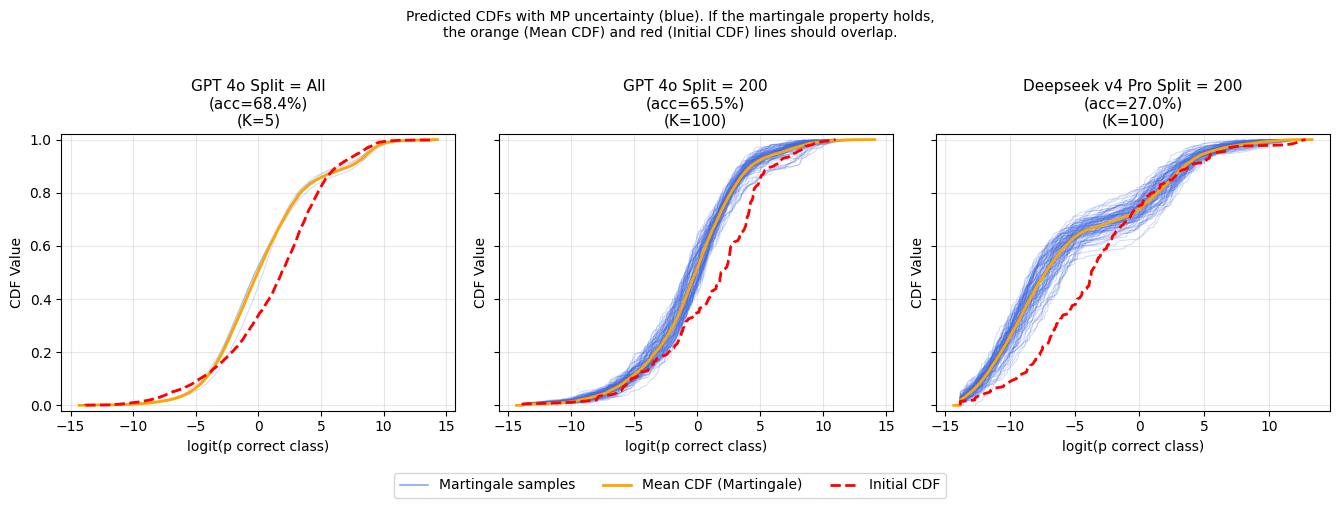

In [8]:
# ── Build figure ──────────────────────────────────────────────────────────────

n_models = len(MODELS)
fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4.5), sharey=True)

if n_models == 1:
    axes = [axes]

for ax, (model_name, npz_path) in zip(axes, MODELS):
    npz_path = Path(npz_path)

    distributions, true_labels, K = load_and_aggregate(str(npz_path), seeds=SEEDS)
    print(f"{model_name}: N={distributions.shape[0]}, K={K}, C={distributions.shape[2]}")
    if not npz_path.exists():
        ax.text(0.5, 0.5, f"File not found:\n{npz_path}",
                ha="center", va="center", transform=ax.transAxes, color="red", fontsize=9)
        ax.set_title(f'{model_name}', fontsize=11)
        continue

    plot_model_cdfs(ax, distributions, true_labels, K, title=model_name)

# Shared legend below all subplots
handles, labels = axes[0].get_legend_handles_labels()
# Add a proxy for the blue iteration lines
import matplotlib.lines as mlines
blue_proxy = mlines.Line2D([], [], color="royalblue", alpha=0.6, linewidth=1.2)
handles = [blue_proxy] + handles
labels  = ["Martingale samples"] + labels

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, -0.08),
    frameon=True,
    fontsize=10,
)

fig.suptitle(
    "Predicted CDFs with MP uncertainty (blue). If the martingale property holds,\n"
    "the orange (Mean CDF) and red (Initial CDF) lines should overlap.",
    y=1.02, fontsize=10,
)

plt.tight_layout()

if SAVE_PATH is not None:
    out = Path(SAVE_PATH)
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, bbox_inches="tight", dpi=150)
    print(f"Saved to {out}")
plt.show()

In [87]:
data = np.load("/Users/alicansahin/Desktop/martingale_results/obqa_gpt40/split_200/martingale_results.npz", allow_pickle=True)

In [88]:
data = data['1'].item()

In [89]:
data.keys()

dict_keys(['distributions', 'true_labels', 'data_indices', 'input_texts', 'prompt_history', 'K', 'mean_tv', 'pass_rate_tv_005', 'pass_rate_tv_010', 'mean_l1', 'accuracy_at_p0', 'tv_per_question', 'mean_l1_per_question', 'drift_profile', 'class_variance'])

In [90]:
data['distributions'][0]

array([[6.04234338e-02, 8.60597551e-01, 4.56099994e-02, 3.33689898e-02],
       [6.54862225e-01, 3.45088124e-01, 2.48285960e-05, 2.48285960e-05],
       [4.64826971e-01, 5.35012543e-01, 8.02449358e-05, 8.02449358e-05],
       [5.79889476e-01, 2.73920387e-01, 4.54204530e-02, 1.00769684e-01],
       [8.83649409e-01, 6.20419271e-02, 2.21217293e-02, 3.21869291e-02],
       [8.84103119e-01, 8.75380635e-02, 1.40686464e-02, 1.42901959e-02],
       [8.48870754e-01, 1.34310856e-01, 1.68109741e-02, 7.41466374e-06],
       [9.23537195e-01, 5.12946285e-02, 1.19946543e-02, 1.31735504e-02],
       [9.14469838e-01, 6.62439689e-02, 1.92780942e-02, 8.11274549e-06],
       [8.92947376e-01, 6.57035336e-02, 2.06745341e-02, 2.06745341e-02],
       [8.78656864e-01, 9.55495015e-02, 1.15914699e-02, 1.42021654e-02],
       [8.54713619e-01, 7.95007497e-02, 2.58101150e-02, 3.99754904e-02],
       [6.88381732e-01, 2.37898350e-01, 3.42725068e-02, 3.94474156e-02],
       [7.08278000e-01, 2.33565301e-01, 2.70371456e

In [91]:
np.log(data['distributions'][0])

array([[ -2.8063784 ,  -0.1501283 ,  -3.0876284 ,  -3.4001284 ],
       [ -0.4233304 ,  -1.0639554 , -10.603515  , -10.603515  ],
       [ -0.76609004,  -0.6254651 ,  -9.430427  ,  -9.430427  ],
       [ -0.54491776,  -1.2949178 ,  -3.0917928 ,  -2.2949178 ],
       [ -0.12369489,  -2.779945  ,  -3.811195  ,  -3.436195  ],
       [ -0.12318157,  -2.4356816 ,  -4.263807  ,  -4.2481813 ],
       [ -0.16384834,  -2.0075984 ,  -4.0857234 , -11.812051  ],
       [ -0.0795442 ,  -2.9701693 ,  -4.423294  ,  -4.329544  ],
       [ -0.0894108 ,  -2.7144108 ,  -3.9487858 , -11.7220745 ],
       [ -0.11322763,  -2.7226026 ,  -3.8788526 ,  -3.8788526 ],
       [ -0.12936082,  -2.348111  ,  -4.4574857 ,  -4.2543607 ],
       [ -0.15698881,  -2.5319889 ,  -3.6569889 ,  -3.2194889 ],
       [ -0.37341174,  -1.4359118 ,  -3.373412  ,  -3.2327867 ],
       [ -0.3449186 ,  -1.4542936 ,  -3.6105435 ,  -3.4699187 ],
       [ -0.31145686,  -1.7333319 ,  -3.295832  ,  -2.920832  ],
       [ -0.23814435,  -1

In [92]:
data['prompt_history'][0]

array(['Return the label of the correct answer for the question below.\n\nQuestion: When the moon, sun, and earth line up, tides are at their\nChoices:\nA) lower\nB) increased\nC) gone away\nD) just okay\nAnswer:',
       'Return the label of the correct answer for the question below.\n\nQuestion: When the moon, sun, and earth line up, tides are at their\nChoices:\nA) lower\nB) increased\nC) gone away\nD) just okay\nYour previous answers were: B\nAnswer:',
       'Return the label of the correct answer for the question below.\n\nQuestion: When the moon, sun, and earth line up, tides are at their\nChoices:\nA) lower\nB) increased\nC) gone away\nD) just okay\nYour previous answers were: B, B\nAnswer:',
       'Return the label of the correct answer for the question below.\n\nQuestion: When the moon, sun, and earth line up, tides are at their\nChoices:\nA) lower\nB) increased\nC) gone away\nD) just okay\nYour previous answers were: B, B, A\nAnswer:',
       'Return the label of the correc